In [ ]:
import pandas as pd

df_delivery = pd.read_csv('../data/delivery_delay_review_summary.csv')

In [3]:
print(df_delivery.shape)
print(df_delivery.head())
print(df_delivery.dtypes)
print(df_delivery.isna().sum())

(95830, 3)
                           order_id  review_score  delivery_delay_days
0  0005a1a1728c9d785b8e2b08b904576c           1.0                    0
1  000aed2e25dbad2f9ddb70584c5a2ded           1.0                   -4
2  00169e31ef4b29deaae414f9a5e95929           1.0                  -15
3  0017afd5076e074a48f1f1a4c7bac9c5           1.0                    4
4  001d8f0e34a38c37f7dba2a37d4eba8b           1.0                    2
order_id                   str
review_score           float64
delivery_delay_days      int64
dtype: object
order_id               0
review_score           0
delivery_delay_days    0
dtype: int64


In [5]:
df_delivery.groupby("review_score")[["delivery_delay_days"]].describe()

delivery_delay_days                                           \
                           count       mean        std    min   25%   50%   
review_score                                                                
1.0                       9316.0  -4.026191  16.064683  -69.0 -14.0  -7.0   
2.0                       2924.0  -8.628249  12.649204  -56.0 -15.0 -10.0   
3.0                       7947.0 -10.767963  10.384977 -135.0 -16.0 -11.0   
4.0                      18892.0 -12.381431   9.064218  -75.0 -17.0 -12.0   
5.0                      56751.0 -13.383112   8.153549 -147.0 -18.0 -13.0   

                          
              75%    max  
review_score              
1.0           6.0  175.0  
2.0          -3.0  188.0  
3.0          -6.0  162.0  
4.0          -7.0  161.0  
5.0          -8.0  155.0

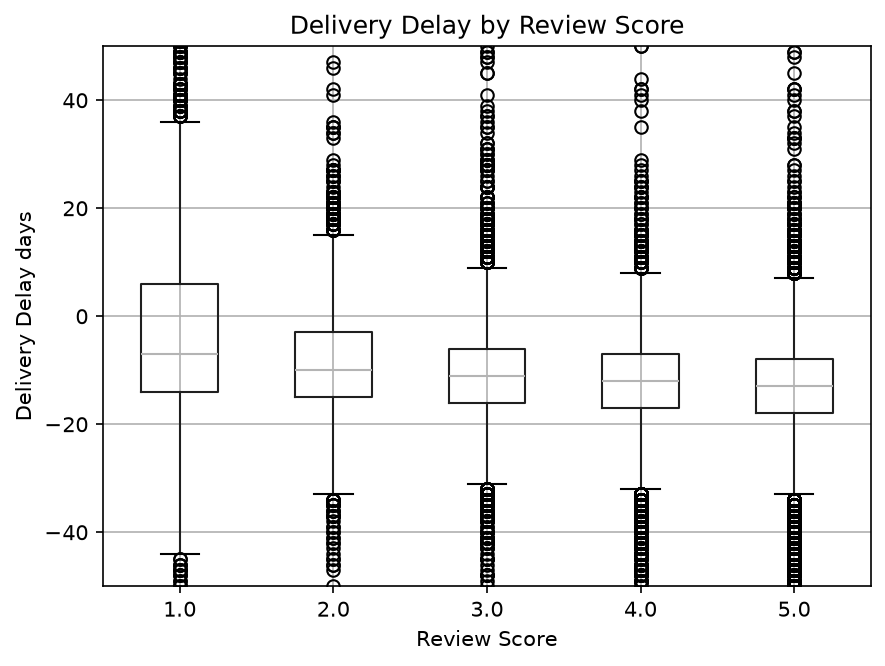

In [11]:
import matplotlib.pyplot as plt

df_delivery.boxplot(
    column="delivery_delay_days",
    by="review_score"
)
plt.ylim(-50, 50)

plt.title("Delivery Delay by Review Score")
plt.suptitle("")
plt.xlabel("Review Score")
plt.ylabel("Delivery Delay days")
plt.show()

In [15]:
from scipy.stats import kruskal

groups_delivery_delay = [
    group["delivery_delay_days"].values
    for _, group in df_delivery.groupby("review_score")
]

stat_delivery_delay, p_delivery_delay = kruskal(*groups_delivery_delay)

print("== Kruskal-Wallis Test ==")
print()
print("[Delivery Delay Days]")
print(f"H-statistic: {stat_delivery_delay:.4f}")
print(f"p-value: {p_delivery_delay:.3e}")

== Kruskal-Wallis Test ==

[Delivery Delay Days]
H-statistic: 3890.1397
p-value: 0.000e+00


In [ ]:
import scikit_posthocs as sp

dunn_delivery = sp.posthoc_dunn(
    df_delivery,
    val_col="delivery_delay_days",
    group_col="review_score",
    p_adjust="bonferroni"
)

dunn_delivery

,1.0,2.0,3.0,4.0,5.0
1.0,1.000000e+00,8.827959e-34,2.637844e-148,0.000000e+00,0.000000e+00
2.0,8.827959e-34,1.000000e+00,2.679655e-09,8.721660e-45,3.226815e-96
3.0,2.637844e-148,2.679655e-09,1.000000e+00,1.241987e-26,1.246768e-103
4.0,0.000000e+00,8.721660e-45,1.241987e-26,1.000000e+00,2.455354e-41
5.0,0.000000e+00,3.226815e-96,1.246768e-103,2.455354e-41,1.000000e+00


In [31]:
median_summary_delivery = (
    df_delivery
    .groupby("review_score")[["delivery_delay_days"]]
    .median()
)

median_summary_delivery["ddd_diff_vs_5"] = (
    median_summary_delivery["delivery_delay_days"]
    - median_summary_delivery.loc[5, "delivery_delay_days"]
)

median_summary_delivery

,delivery_delay_days,ddd_diff_vs_5
review_score,,
1.0,-7.0,6.0
2.0,-10.0,3.0
3.0,-11.0,2.0
4.0,-12.0,1.0
5.0,-13.0,0.0


In [24]:
mean_summary_ddd = (
    df_delivery
    .groupby("review_score")[["delivery_delay_days"]]
    .mean()
)

mean_summary_ddd["ddd_diff_vs_5"] =(
    mean_summary_ddd["delivery_delay_days"]
    - mean_summary_ddd.loc[5, "delivery_delay_days"]
)

mean_summary_ddd

,delivery_delay_days,ddd_diff_vs_5
review_score,,
1.0,-4.026191,9.356921
2.0,-8.628249,4.754863
3.0,-10.767963,2.615149
4.0,-12.381431,1.001681
5.0,-13.383112,0.000000


In [32]:

N = len(df_delivery)
K = df_delivery["review_score"].nunique()

epsilon_delivery = (stat_delivery_delay - K + 1) / (N - K)

print(f"Delivery Delay Days  ε²: {epsilon_delivery:.6f}")

Delivery Delay Days  ε²: 0.040555
